In [1]:
import random
import math
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import copy
import pandas as pd  
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from pyswarm import pso

In [2]:
# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85train_data新.xlsx')
# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85test_data新.xlsx')
x_train=train_data[['Si', 'Mn', 'Al','Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train=train_data['Time to Rupture(h)']
x_test=test_data[['Si', 'Mn', 'Al','Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test=test_data['Time to Rupture(h)']

In [3]:
# 假设 x_train, y_train, x_test, y_test 已经定义并准备好# 定义你希望调优的参数范围
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 100, 150],
    'gamma': [0, 0.1, 0.2],
    'alpha': [0, 0.1, 0.2],
    'lambda': [0, 0.1, 0.2]
}

# 创建XGBoost回归模型实例
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror')

# 将模型和参数范围传入 GridSearchCV，并设置交叉验证数量为 5
grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')

# 使用训练数据拟合 GridSearchCV
grid_search.fit(x_train, y_train)

# 打印最佳参数组合
print(f"Best parameters: {grid_search.best_params_}")

# 使用最优参数在所有训练数据上重新训练模型
best_xgb_reg = grid_search.best_estimator_

# 如果使用xgb.train，则需使用以下代码
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

# 设置参数（使用上面GridSearchCV得到的最优参数）
best_params = grid_search.best_params_
best_params["objective"] = "reg:squarederror"

bst = xgb.train(best_params,
                dtrain,
                num_boost_round=100,
                evals=[(dtest, "test")],
                early_stopping_rounds=10,
                verbose_eval=False)

# 对测试集进行预测
preds = best_xgb_reg.predict(x_test)

# 计算并打印均方误差和确定系数（R-squared）
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("xgboost RMSE: %f" % (rmse))
print("xgboost R2: %f" % (r2))

# 定义PSO优化目标函数
def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_child_weight = int(particle_position[3])
    subsample = particle_position[4]
    gamma = particle_position[5]

    model = xgb.XGBRegressor(max_depth=max_depth,
                             learning_rate=learning_rate,
                             n_estimators=n_estimators,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             gamma=gamma)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

# 定义PSO的上下界
lb = [1, 0.001, 50, 1, 0.1, 0]
ub = [10, 0.5, 500, 10, 1, 1]

# 运行PSO优化
xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

# 使用PSO优化后的参数重新训练模型
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_child_weight = int(xopt[3])
subsample = xopt[4]
gamma = xopt[5]

model_optimal = xgb.XGBRegressor(max_depth=max_depth,
                                 learning_rate=learning_rate,
                                 n_estimators=n_estimators,
                                 min_child_weight=min_child_weight,
                                 subsample=subsample,
                                 gamma=gamma)
model_optimal.fit(x_train, y_train)

# 预测测试集
y_pred_optimal = model_optimal.predict(x_test)

# 评估PSO优化后的模型性能
mse_optimal = mean_squared_error(y_test, y_pred_optimal)
mae_optimal = mean_absolute_error(y_test, y_pred_optimal)
r2_optimal = r2_score(y_test, y_pred_optimal)

print(f"PSO Optimized Model - Mean Squared Error (MSE): {mse_optimal:.5f}")
print(f"PSO Optimized Model - Mean Absolute Error (MAE): {mae_optimal:.5f}")
print(f"PSO Optimized Model - R2 Score: {r2_optimal:.5f}")


Best parameters: {'alpha': 0.2, 'gamma': 0, 'lambda': 0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 150}


C:\Users\zangd\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:160: UserWarning: [10:17:43] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


xgboost RMSE: 8071.806377
xgboost R2: 0.941703
Stopping search: maximum iterations reached --> 100
Found optimal solution:  [8.80153888e+00 1.49421098e-01 4.70127032e+02 1.11482173e+00
 6.19175942e-01 4.58850147e-01]
Objective function at optimal solution:  32158618.45601376
PSO Optimized Model - Mean Squared Error (MSE): 32158618.45601
PSO Optimized Model - Mean Absolute Error (MAE): 2700.06755
PSO Optimized Model - R2 Score: 0.97123


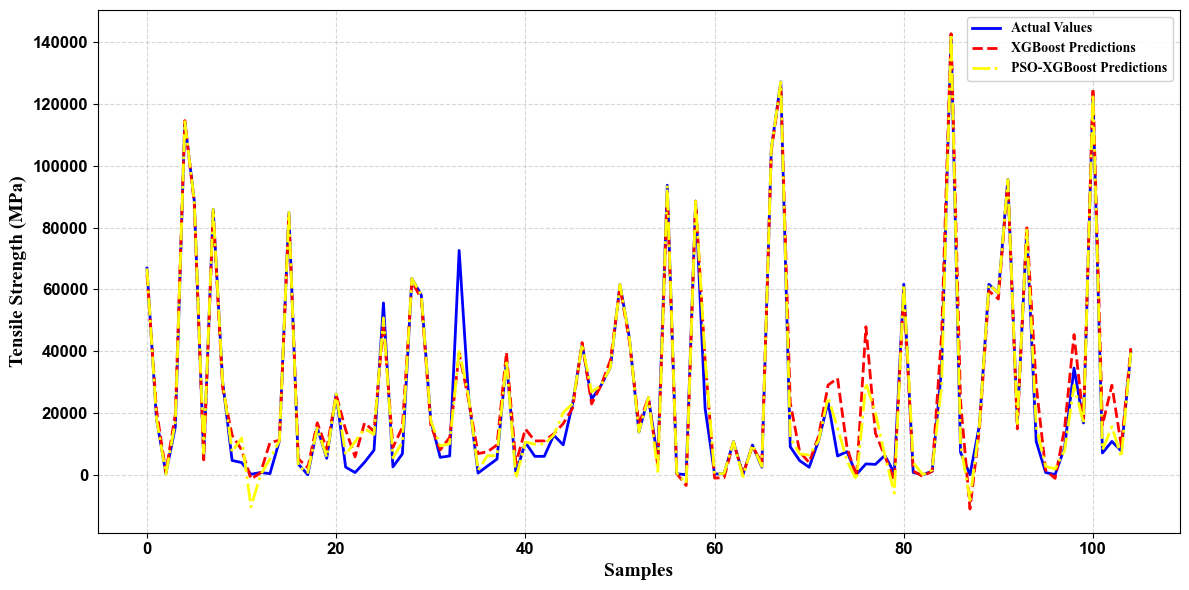

In [4]:
# 绘制真实值与预测值的对比图
plt.figure(figsize=(12, 6))

# 真实值
plt.plot(y_test.values, label='Actual Values', color='blue', linewidth=2)

# XGBoost模型的预测值
plt.plot(preds, label='XGBoost Predictions', color='red', linestyle='--', linewidth=2)

# PSO优化后的XGBoost模型的预测值
plt.plot(y_pred_optimal, label='PSO-XGBoost Predictions', color='yellow', linestyle='-.', linewidth=2)
  
plt.xlabel('Samples', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('Creep Rupture Time (h)', fontsize=14, fontweight='bold', fontname='Times New Roman')

# 设置图例
legend = plt.legend(loc='upper right', fontsize=12, prop={'family': 'Times New Roman', 'weight': 'bold'})
legend.get_frame().set_alpha(0.9)  # 设置图例背景透明度

# 美化坐标轴
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.5)

# 自动调整图表布局
plt.tight_layout()

# 保存图片
plt.savefig(r'D:\creep rupture\Actual_vs_Predicted_TR对比.png', dpi=300, format='png', bbox_inches='tight')
plt.savefig(r'D:\creep rupture\Actual_vs_Predicted_TR对比.pdf', dpi=300, format='pdf', bbox_inches='tight')

# 显示图形
plt.show()

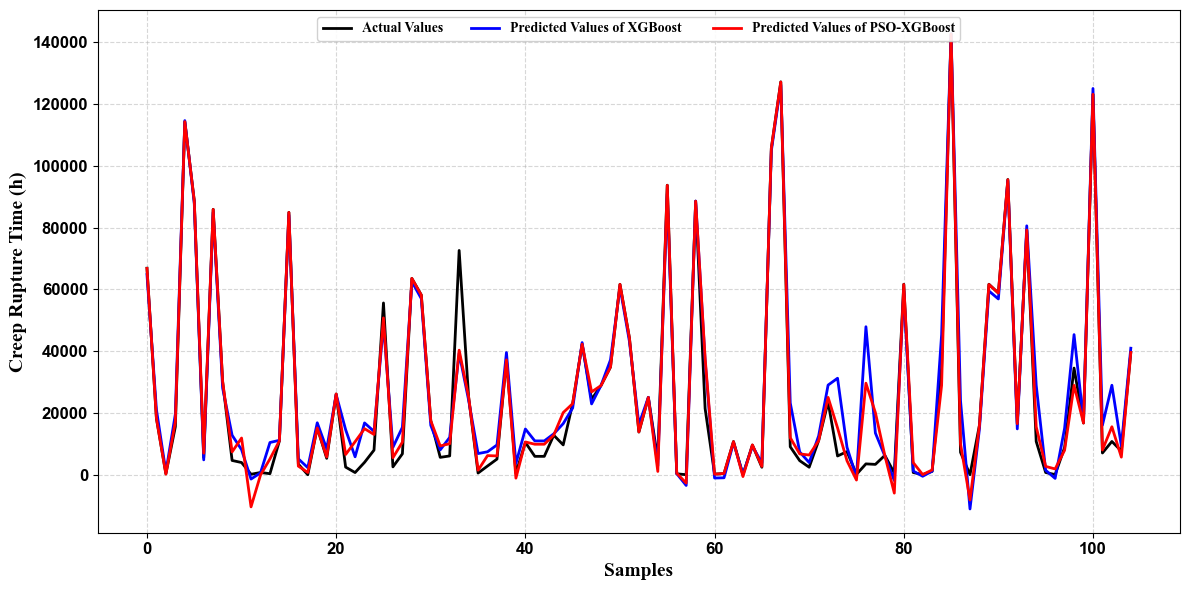

In [9]:
# 绘制真实值与预测值的对比图
plt.figure(figsize=(12, 6))

# 真实值
plt.plot(y_test.values, label='Actual Values', color='black', linewidth=2)

# XGBoost模型的预测值
plt.plot(preds, label='Predicted Values of XGBoost ', color='blue',linewidth=2)

# PSO优化后的XGBoost模型的预测值
plt.plot(y_pred_optimal, label='Predicted Values of PSO-XGBoost', color='red',linewidth=2)

# 添加标题和标签
plt.xlabel('Samples', fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel('Creep Rupture Time (h)', fontsize=14, fontweight='bold', fontname='Times New Roman')

# 设置图例，将其放置在图内上边中间位置
legend = plt.legend(loc='upper center',fontsize=12, prop={'family': 'Times New Roman', 'weight': 'bold'}, ncol=3)
legend.get_frame().set_alpha(0.9)  # 设置图例背景透明度

# 美化坐标轴
plt.xticks(fontsize=12, fontname='Arial', fontweight='bold')
plt.yticks(fontsize=12, fontname='Arial', fontweight='bold')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.5)

# 自动调整图表布局
plt.tight_layout()

# 保存图片
plt.savefig(r'D:\creep rupture\Actual_vs_Predicted_TR对比.png', dpi=300, format='png', bbox_inches='tight')
plt.savefig(r'D:\creep rupture\Actual_vs_Predicted_TR对比.pdf', dpi=300, format='pdf', bbox_inches='tight')

# 显示图形
plt.show()